In [2]:
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import astropy.units as u
from astropy.io import fits
import pickle
import arviz as az
from spectres import spectres
import os
import glob
import re

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


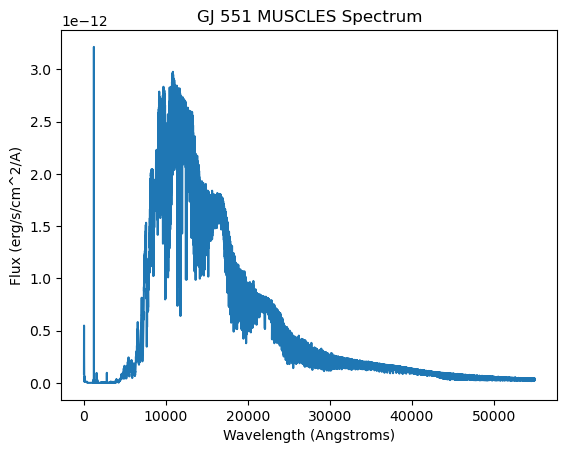

In [3]:
proxima_spec = fits.getdata('hlsp_muscles_multi_multi_gj551_broadband_v22_adapt-const-res-sed.fits',1)
plt.plot(proxima_spec['WAVELENGTH'],proxima_spec['FLUX'])
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (erg/s/cm^2/A)')
plt.title('GJ 551 MUSCLES Spectrum')
plt.show()

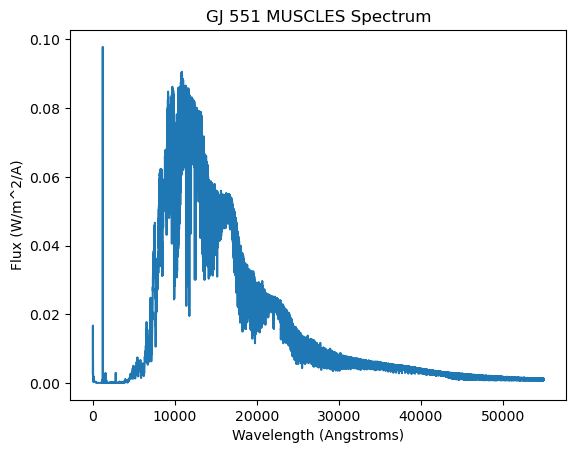

In [29]:
R_prox_cent_b = 1.07 * 6371.
a_prox_cent_b = 0.04856 * 150E9
P_prox_cent_b = 11.1868
dist_prox_cent_b = 1.30197
R_prox_star = 0.141 * 695508

proxima_spec_w = proxima_spec['FLUX'] *1E-7 * 100 ** 2 * (dist_prox_cent_b * 3.0857E16) ** 2 / (a_prox_cent_b) ** 2


plt.plot(proxima_spec['WAVELENGTH'],proxima_spec_w)
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (W/m^2/A)')
plt.title('GJ 551 MUSCLES Spectrum')
plt.show()

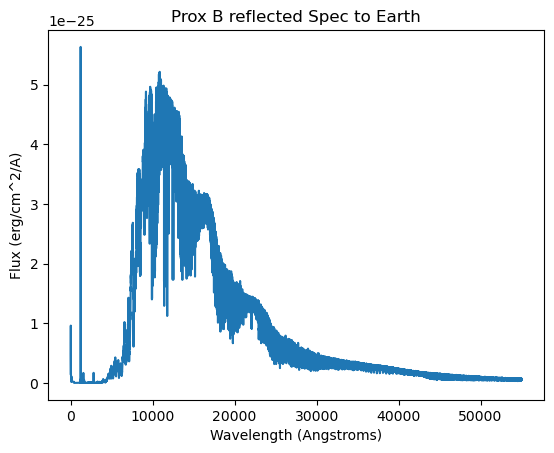

In [37]:
proxb_spec_erg = proxima_spec['FLUX'] * (dist_prox_cent_b * 3.0857E16) ** 2 / (a_prox_cent_b) ** 2

albedo = 0.2

proxb_spec_refl = proxb_spec_erg *  albedo * R_prox_cent_b ** 2 / (dist_prox_cent_b * 3.0857E16) ** 2

plt.plot(proxima_spec['WAVELENGTH'],proxb_spec_refl)
plt.xlabel('Wavelength (Angstroms)')
plt.ylabel('Flux (erg/cm^2/A)')
plt.title('Prox B reflected Spec to Earth')
plt.show()

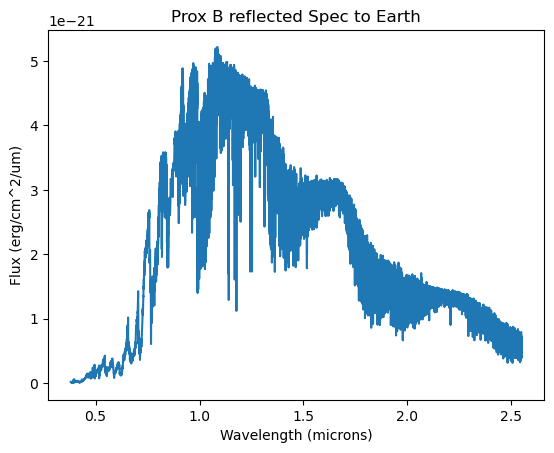

In [38]:
prox_wav = proxima_spec['WAVELENGTH']/10./1000.

index = np.where((prox_wav > 0.38) & (prox_wav < 2.55))

prox_wav = prox_wav[index]
prox_b_flux_to_earth = proxb_spec_refl[index] * 10 * 1000

plt.plot(prox_wav,prox_b_flux_to_earth)
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux (erg/cm^2/um)')
plt.title('Prox B reflected Spec to Earth')
plt.show()

/var/folders/9n/l_gsk58x7zx9nz635n3gcs_00000gn/T/ipykernel_3681/3429508184.py:1: RuntimeWarning: divide by zero encountered in log10
  proxb_mag_AB = -2.5 * np.log10(proxima_spec['FLUX'] * 10000. * 2E-7) - 5.0 * np.log10(proxima_spec['WAVELENGTH']/10000.) - 12.4


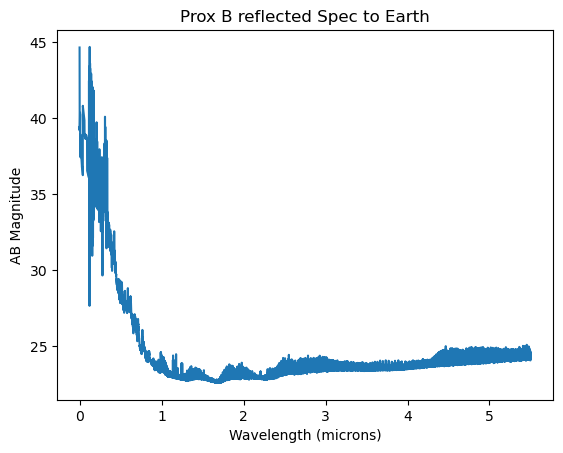

In [9]:
proxb_mag_AB = -2.5 * np.log10(proxima_spec['FLUX'] * 10000. * 2E-7) - 5.0 * np.log10(proxima_spec['WAVELENGTH']/10000.) - 12.4

plt.plot(proxima_spec['WAVELENGTH']/10000.,proxb_mag_AB)
plt.xlabel('Wavelength (microns)')
plt.ylabel('AB Magnitude')
plt.title('Prox B reflected Spec to Earth')
plt.show()


In [42]:
prox_flux_erg = proxima_spec['FLUX'][np.where((proxima_spec['WAVELENGTH'] > 3800) & (proxima_spec['WAVELENGTH'] < 25500))]

In [10]:
np.savetxt('proxb_mag_albedo2E-7_from_starry_mod.txt',np.array([proxima_spec['WAVELENGTH']/10000.,proxb_mag_AB]).T)

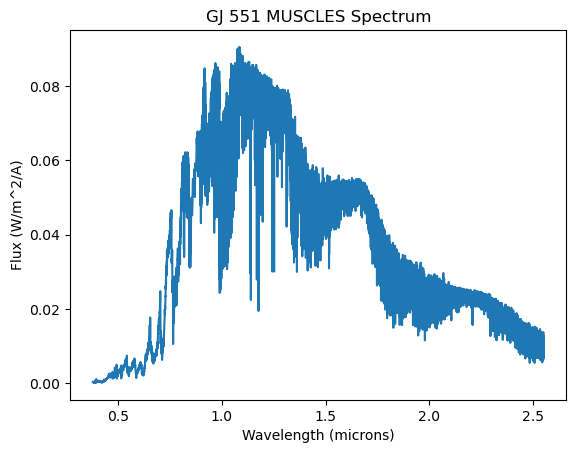

In [30]:
prox_wav = proxima_spec['WAVELENGTH']/10./1000.

index = np.where((prox_wav > 0.38) & (prox_wav < 2.55))

prox_wav = prox_wav[index]
prox_flux = proxima_spec_w[index]

plt.plot(prox_wav,prox_flux)
plt.xlabel('Wavelength (microns)')
plt.ylabel('Flux (W/m^2/A)')
plt.title('GJ 551 MUSCLES Spectrum')
plt.show()

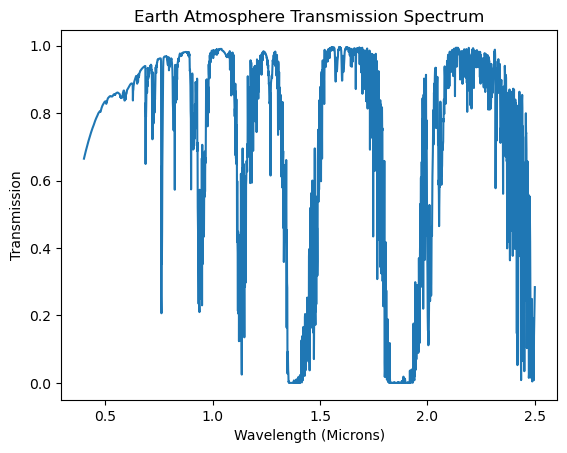

In [6]:
trans_spec_wav, trans_spec, _, _, _, _, _, _, _, _, _, _ = np.loadtxt('trans_w_earth_atm_1nm.txt', unpack=True, skiprows=7)

trans_spec = trans_spec[trans_spec_wav < 2.55]
trans_spec_wav = trans_spec_wav[trans_spec_wav < 2.55]

plt.plot(trans_spec_wav, trans_spec)
plt.xlabel('Wavelength (Microns)')
plt.ylabel('Transmission')
plt.title('Earth Atmosphere Transmission Spectrum')
plt.show()

In [7]:
def wav_grid_from_R(R, wav_min, wav_max):
    N = int(np.log(wav_max/wav_min)/np.log(R/(R-1)))
    wav_max = wav_min * (R / (R - 1)) ** (N)
    wav = np.geomspace(wav_min, wav_max, int(N), endpoint = True)
    return wav

def resample_to_R(R, wav, spec, spec_err = None, wav_min = None, wav_max = None, stack = False):
    if wav_min is None:
        wav_min = wav[0]
    if wav_max is None:
        wav_max = wav[-1]

    wav_grid = wav_grid_from_R(R, wav_min, wav_max)

    if spec_err is not None:
        spec_resamp, spec_err_resamp = spectres(wav_grid, wav, spec, spec_errs = spec_err)
        if stack:
            return np.column_stack((wav_grid, spec_resamp, spec_err_resamp))
        else:
            return wav_grid, spec_resamp
    else:
        spec_resamp = spectres(wav_grid, wav, spec)
        if stack:
            return np.column_stack((wav_grid, spec_resamp))
        else:
            return wav_grid, spec_resamp

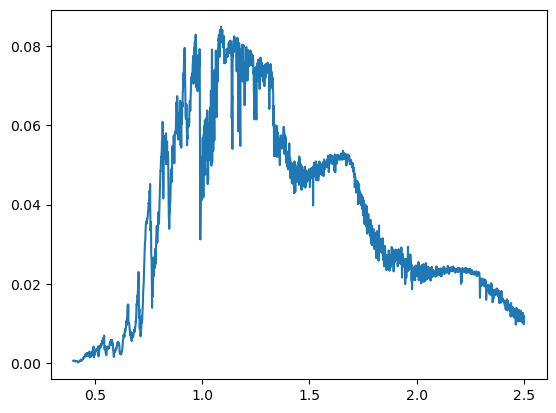

In [8]:
prox_flux = spectres(trans_spec_wav, prox_wav, prox_flux)

plt.plot(trans_spec_wav, prox_flux)
plt.show()

In [9]:
np.isnan(prox_flux).any()

False

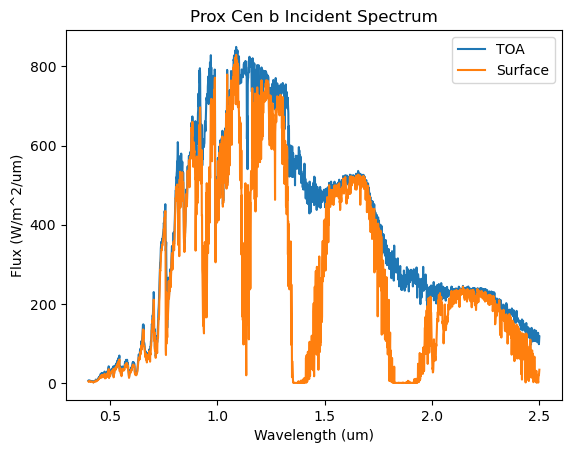

In [10]:
prox_flux *= (10 * 1000)
prox_surface = prox_flux * trans_spec

plt.plot(trans_spec_wav, prox_flux, label = 'TOA')
plt.plot(trans_spec_wav, prox_surface, label = 'Surface')
plt.xlabel('Wavelength (um)')
plt.ylabel('Flux (W/m^2/um)')
plt.title('Prox Cen b Incident Spectrum')
plt.legend()
plt.show()

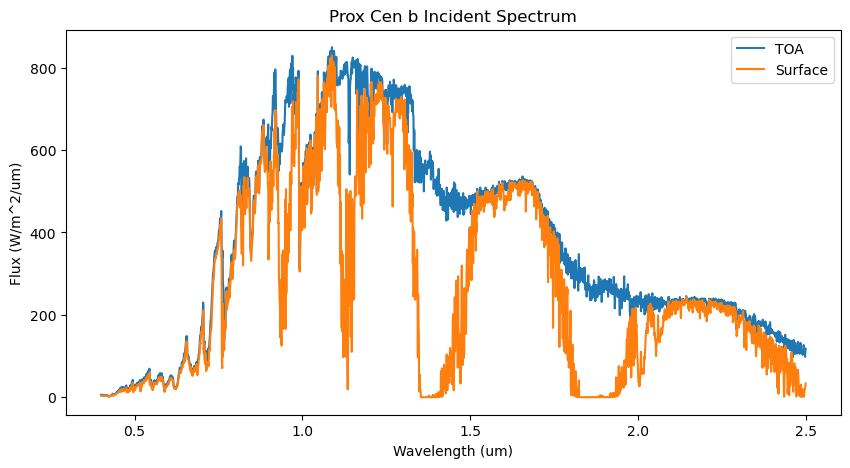

In [11]:
fig = plt.figure(figsize=(10, 5))
plt.plot(trans_spec_wav, prox_flux, label = 'TOA')
plt.plot(trans_spec_wav, prox_surface, label = 'Surface')
plt.xlabel('Wavelength (um)')
plt.ylabel('Flux (W/m^2/um)')
plt.title('Prox Cen b Incident Spectrum')
plt.legend()
plt.show()

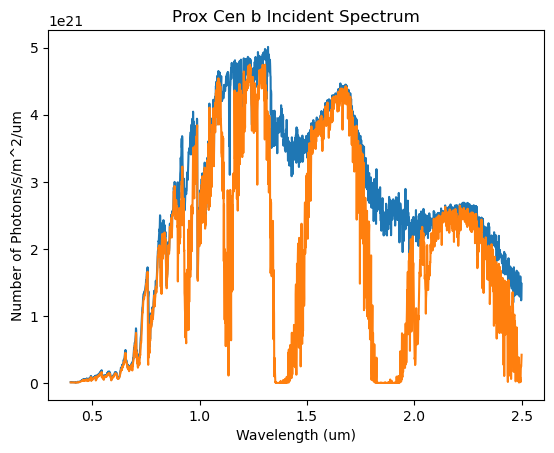

In [21]:
from astropy.constants import h, c 
n_phot = prox_flux * trans_spec_wav * 1E-6 / (h.value * c.value)
n_phot_surface = prox_surface * trans_spec_wav * 1E-6 / (h.value * c.value)

plt.plot(trans_spec_wav, n_phot)
plt.plot(trans_spec_wav, n_phot_surface)
plt.xlabel('Wavelength (um)')
plt.ylabel('Number of Photons/s/m^2/um')
plt.title('Prox Cen b Incident Spectrum')
plt.show()

In [22]:
np.savetxt('prox_cen_b_incident_spec_phot.txt', np.column_stack((trans_spec_wav, n_phot, n_phot_surface)), 
           header = 'Wavelength (um) TOA (n/s/m^2/um) Surface (n/s/m^2/um)')

In [12]:
np.savetxt('prox_cen_b_incident_spec.txt', 
           np.column_stack((trans_spec_wav, prox_flux, prox_surface, trans_spec)), 
           header = 'Wavelength (um), TOA Flux (W/m^2/um), Surface Flux (W/m^2/um), Atmospheric Transmission')

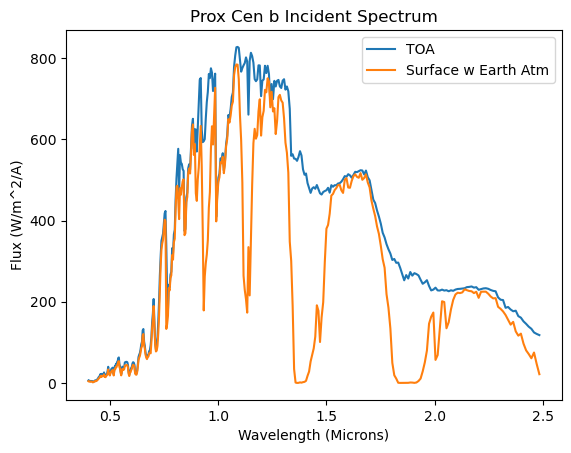

In [46]:
prox_surface *= (10 * 1000)
prox_flux *= (10 * 1000)
trans_spec_wav /= (10 * 1000)

plt.plot(trans_spec_wav, prox_flux, label = 'TOA')
plt.plot(trans_spec_wav, prox_surface, label = 'Surface w Earth Atm')
plt.xlabel('Wavelength (Microns)')
plt.ylabel('Flux (W/m^2/A)')
plt.title('Prox Cen b Incident Spectrum')
plt.legend()
plt.show()

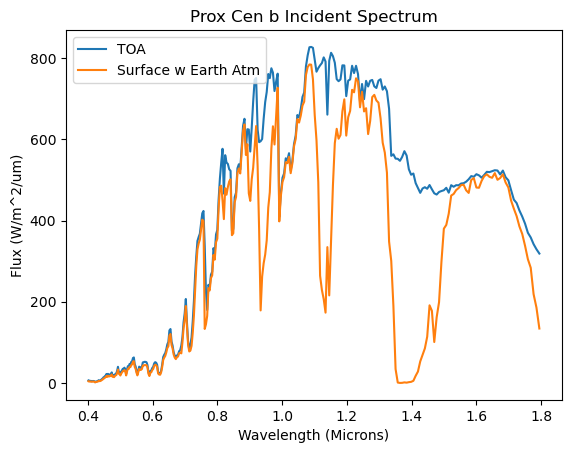

In [49]:
plt.plot(trans_spec_wav[trans_spec_wav < 1.8], prox_flux[trans_spec_wav < 1.8], label = 'TOA')
plt.plot(trans_spec_wav[trans_spec_wav < 1.8], prox_surface[trans_spec_wav < 1.8], label = 'Surface w Earth Atm')
plt.xlabel('Wavelength (Microns)')
plt.ylabel('Flux (W/m^2/um)')
plt.title('Prox Cen b Incident Spectrum')
plt.legend()
plt.show()

In [41]:
sed_wav, sed_flux = np.loadtxt('proxima_cen_sed_1AU.txt', unpack=True, skiprows=25)

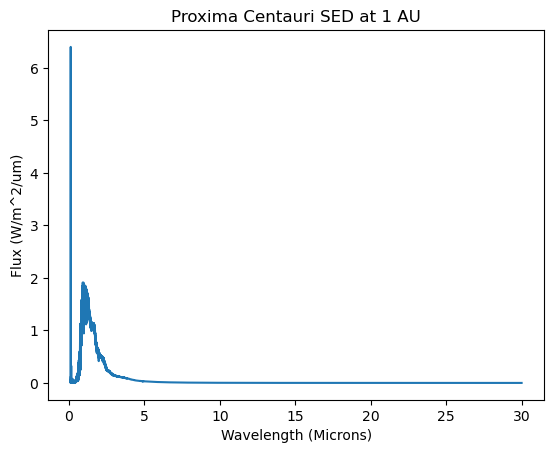

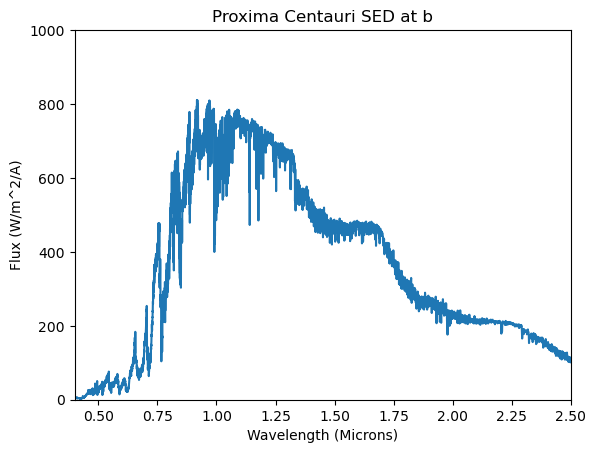

In [44]:
plt.plot(sed_wav, sed_flux)
plt.xlabel('Wavelength (Microns)')
plt.ylabel('Flux (W/m^2/um)')
plt.title('Proxima Centauri SED at 1 AU')
plt.show()

sed_flux_atb = sed_flux / 0.04856 ** 2

plt.plot(sed_wav, sed_flux_atb)
plt.xlabel('Wavelength (Microns)')
plt.xlim(0.4,2.5)
plt.ylim(0, 1000)
plt.ylabel('Flux (W/m^2/um)')
plt.title('Proxima Centauri SED at b')
plt.show()

In [45]:
print(0.08 * 10 * 1000)

800.0


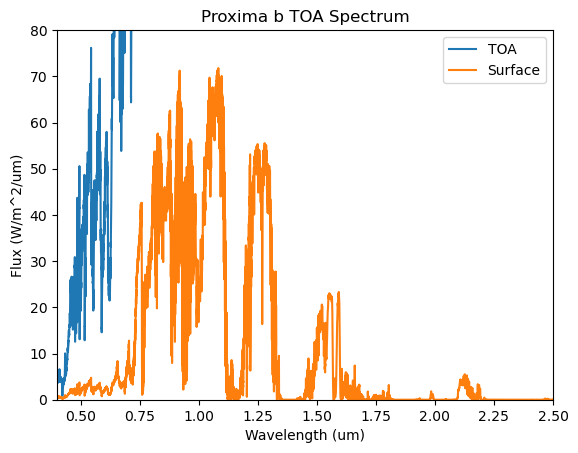

In [19]:
plt.plot(wav,toa, label = 'TOA')
plt.plot(wav, surface, label='Surface')
plt.
plt.xlabel('Wavelength (um)')
plt.ylabel('Flux (W/m^2/um)')
plt.title('Proxima b TOA Spectrum')
plt.xlim(0.4, 2.5)
plt.ylim(0, 80)
plt.legend()
plt.show()

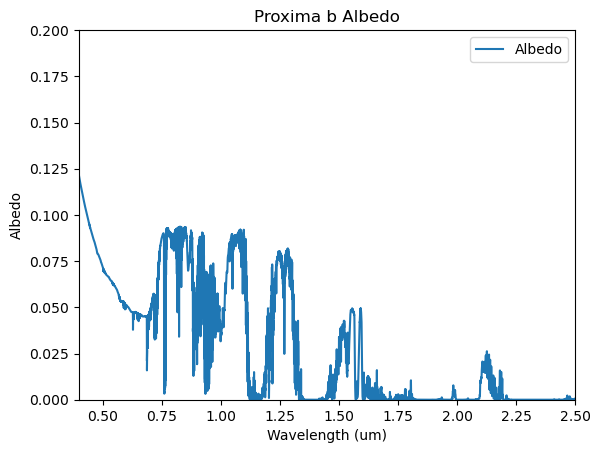

In [21]:
plt.plot(wav,albedo, label = 'Albedo')
plt.xlabel('Wavelength (um)')
plt.ylabel('Albedo')
plt.title('Proxima b Albedo')
plt.xlim(0.4, 2.5)
plt.ylim(0, 0.2)
plt.legend()
plt.show()